# Overview Plots: Publication Figures for the diffsed Paper

This notebook creates the "money plots" --- comprehensive figures that
showcase **diffsed**'s capabilities for the paper.  Each figure is
designed to be self-contained, publication-quality, and suitable for
direct inclusion in the manuscript.

## Figures

1. **Full forward model pipeline** --- All physics modules applied
   progressively to a single star-forming galaxy at $z=1$.
2. **Dust attenuation curve comparison** --- All 7 curves normalized
   at $V$-band, with UV bump inset.
3. **AGN model zoo** --- All 6 AGN models at the same $L_{\rm bol}$.
4. **Parameter degeneracies** --- Classic SED-fitting degeneracies
   in age--dust, AGN--dust, $Z$--age, and AGN--SFR.
5. **Wavelength coverage** --- Full panchromatic SED from X-ray to radio.
6. **Filter library** --- All major filter sets overlaid on a template
   galaxy SED.

In [1]:
import os
import sys
import warnings

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

sys.path.insert(0, ".")
from _plot_style import COLORS, setup_style

setup_style()

# Publication style overrides
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
})

# Output directories
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(fig, name, dpi=300):
    """Save figure in both PNG and PDF formats."""
    for ext in ("png", "pdf"):
        path = os.path.join(FIG_DIR, f"18_{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figures/18_{name}.png and .pdf")

In [2]:
# Load SSP data and suppress fused-kernel warnings for exact-path models
from diffsed import (
    Fixed, Model, ParamSpec, Uniform,
    load_filter_set, load_ssp_data,
)
from diffsed.models.dust.attenuation import DUST_LAWS
from diffsed.models.agn import AGN_MODELS, get_agn_model
from diffsed.models.igm import igm_transmission
from diffsed.models.observation.filters import FILTER_REGISTRY, load_filter

SSP_PATH = "../data/fsps_prsc_miles_chabrier.h5"
CLOUDY_PATH = "../data/cloudy_grid_mist.h5"

ssp = load_ssp_data(SSP_PATH)
print(f"SSP wave range: {float(ssp.ssp_wave.min()):.0f} -- "
      f"{float(ssp.ssp_wave.max()):.0f} Angstrom ({len(ssp.ssp_wave)} pixels)")

SSP wave range: 91 -- 100000000 Angstrom (5994 pixels)


---
## Figure 1: The Full Forward Model Pipeline

A single figure showing every physics module applied progressively to
one star-forming galaxy at $z=1$ with dust, nebular emission, AGN,
IR dust emission (DL07), and IGM absorption.  The SED is built up
as a sequence of stacked components.

In [3]:
# Define filter sets for overlay
filter_names_fig1 = [
    "galex_fuv", "galex_nuv",
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "jwst_f090w", "jwst_f115w", "jwst_f150w", "jwst_f200w",
    "jwst_f277w", "jwst_f356w", "jwst_f444w",
    "wise_w1", "wise_w2", "wise_w3", "wise_w4",
]

# Load filters for overlay
filter_curves_fig1 = []
for fn in filter_names_fig1:
    try:
        fc = load_filter(fn)
        filter_curves_fig1.append(fc)
    except Exception as e:
        print(f"Skipping filter {fn}: {e}")

In [4]:
# Build progressive models: each adds one physics layer
# 1) Intrinsic stellar (no dust)
# 2) + Dust attenuation
# 3) + Nebular emission (CLOUDY)
# 4) + Dust IR emission (DL07)
# 5) + AGN
# 6) + IGM absorption (final)

# Common SFH + metallicity params
_base_params = dict(
    mean_sfh_type="dpl",
    sfh_dpl_alpha=Fixed(1.2),
    sfh_dpl_beta=Fixed(1.8),
    sfh_dpl_tau_gyr=Fixed(5.0),
    sfh_dpl_log_peak_sfr=Fixed(1.5),
    met_logzsol=Fixed(-0.3),
    redshift=Fixed(1.0),
)

# Layer 1: Intrinsic stellar only (no dust)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    spec_intrinsic = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.0),
        dust_tau_diff=Fixed(0.0),
        apply_igm=False,
    )
    model_intrinsic = Model(spec_intrinsic, ssp, precompute=False, approx=False)

    # Layer 2: + Dust attenuation
    spec_dust = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.8),
        dust_tau_diff=Fixed(0.4),
        apply_igm=False,
    )
    model_dust = Model(spec_dust, ssp, precompute=False, approx=False)

    # Layer 3: + Nebular emission
    spec_neb = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.8),
        dust_tau_diff=Fixed(0.4),
        cloudy_grid_path=CLOUDY_PATH,
        neb_logU=Fixed(-2.5),
        apply_igm=False,
    )
    model_neb = Model(spec_neb, ssp, precompute=False, approx=False)

    # Layer 4: + Dust IR emission (DL07)
    spec_ir = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.8),
        dust_tau_diff=Fixed(0.4),
        cloudy_grid_path=CLOUDY_PATH,
        neb_logU=Fixed(-2.5),
        dust_emission="draine_li2007",
        dust_umin=Fixed(2.0),
        dust_gamma_dl=Fixed(0.02),
        dust_qpah=Fixed(3.0),
        apply_igm=False,
    )
    model_ir = Model(spec_ir, ssp, precompute=False, approx=False)

    # Layer 5: + AGN
    spec_agn = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.8),
        dust_tau_diff=Fixed(0.4),
        cloudy_grid_path=CLOUDY_PATH,
        neb_logU=Fixed(-2.5),
        dust_emission="draine_li2007",
        dust_umin=Fixed(2.0),
        dust_gamma_dl=Fixed(0.02),
        dust_qpah=Fixed(3.0),
        agn_model="simple",
        agn_lum_ratio=Fixed(0.1),
        apply_igm=False,
    )
    model_agn = Model(spec_agn, ssp, precompute=False, approx=False)

    # Layer 6: + IGM (final model)
    spec_full = ParamSpec(
        **_base_params,
        dust_tau_bc=Fixed(0.8),
        dust_tau_diff=Fixed(0.4),
        cloudy_grid_path=CLOUDY_PATH,
        neb_logU=Fixed(-2.5),
        dust_emission="draine_li2007",
        dust_umin=Fixed(2.0),
        dust_gamma_dl=Fixed(0.02),
        dust_qpah=Fixed(3.0),
        agn_model="simple",
        agn_lum_ratio=Fixed(0.1),
        apply_igm=True,
    )
    model_full = Model(spec_full, ssp, precompute=False, approx=False)

In [5]:
# Generate parameter sample
key = jax.random.PRNGKey(42)
params = spec_full.sample(key)

# Compute each SED layer
sed_intrinsic = np.array(model_intrinsic.predict_sed(params))
sed_dust = np.array(model_dust.predict_sed(params))
sed_neb = np.array(model_neb.predict_sed(params))
sed_ir = np.array(model_ir.predict_sed(params))
sed_agn = np.array(model_agn.predict_sed(params))

# For the final (IGM) layer, we apply IGM transmission manually
# since predict_sed returns rest-frame and IGM acts on observed frame
z = 1.0
sed_pre_igm = np.array(model_agn.predict_sed(params))
wave_rest = np.array(ssp.ssp_wave)
wave_obs = wave_rest * (1.0 + z)
igm_trans = np.array(igm_transmission(jnp.array(wave_obs), z))
sed_final = sed_pre_igm * igm_trans

# Convert to nu*L_nu for display
c_aa = 2.99792458e18  # c in Angstrom/s
nu_ssp = c_aa / wave_rest
LSUN = 3.828e33  # erg/s

# Convert from L_nu (Lsun/Hz) to nu*L_nu (Lsun)
nuLnu_intrinsic = sed_intrinsic * nu_ssp
nuLnu_dust = sed_dust * nu_ssp
nuLnu_neb = sed_neb * nu_ssp
nuLnu_ir = sed_ir * nu_ssp
nuLnu_agn = sed_agn * nu_ssp
nuLnu_final = sed_final * nu_ssp

# Convert wavelength to microns for x-axis (SSP grid)
wave_um_ssp = wave_rest / 1e4

<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['agn_T_torus', 'agn_alpha', 'agn_cos_inc', 'agn_lum_ratio', 'agn_log_lbol', 'agn_log_ledd', 'agn_log_mbh', 'agn_oa_skirtor', 'agn_p_skirtor', 'agn_q_skirtor', 'agn_tau_skirtor', 'agn_tau_torus', 'agn_torus_frac', 'dust_T', 'dust_alpha_dale', 'dust_alpha_dl14', 'dust_alpha_mir', 'dust_beta_ir', 'dust_eta_balance', 'dust_gamma_dl', 'dust_qpah', 'dust_umin', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_logZ_gas']. These will be silently ignored. Did you mean one of: ['dust_Rv', 'dust_bump_strength', 'dust_delta', 'dust_f_obscuration', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'met_alpha_fe', 'met_logzsol', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']?
  return self._compute_sed_components(params)["sed_total"]


<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['agn_T_torus', 'agn_alpha', 'agn_cos_inc', 'agn_lum_ratio', 'agn_log_lbol', 'agn_log_ledd', 'agn_log_mbh', 'agn_oa_skirtor', 'agn_p_skirtor', 'agn_q_skirtor', 'agn_tau_skirtor', 'agn_tau_torus', 'agn_torus_frac', 'dust_T', 'dust_alpha_dale', 'dust_alpha_dl14', 'dust_alpha_mir', 'dust_beta_ir', 'dust_eta_balance', 'dust_gamma_dl', 'dust_qpah', 'dust_umin']. These will be silently ignored. Did you mean one of: ['dust_Rv', 'dust_bump_strength', 'dust_delta', 'dust_f_obscuration', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'met_alpha_fe', 'met_logzsol', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_logZ_gas', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']?
  return self._compute_sed_components(params)["sed_total"]


<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['agn_T_torus', 'agn_alpha', 'agn_cos_inc', 'agn_lum_ratio', 'agn_log_lbol', 'agn_log_ledd', 'agn_log_mbh', 'agn_oa_skirtor', 'agn_p_skirtor', 'agn_q_skirtor', 'agn_tau_skirtor', 'agn_tau_torus', 'agn_torus_frac', 'dust_alpha_dl14']. These will be silently ignored. Did you mean one of: ['dust_Rv', 'dust_T', 'dust_alpha_dale', 'dust_alpha_mir', 'dust_beta_ir', 'dust_bump_strength', 'dust_delta', 'dust_eta_balance', 'dust_f_obscuration', 'dust_gamma_dl', 'dust_qpah', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'dust_umin', 'met_alpha_fe', 'met_logzsol', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_logZ_gas', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']?
  return self._compute_sed_components(params)["sed_total"]


<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['agn_cos_inc', 'agn_oa_skirtor', 'agn_p_skirtor', 'agn_q_skirtor', 'agn_tau_skirtor', 'dust_alpha_dl14']. These will be silently ignored. Did you mean one of: ['agn_T_torus', 'agn_alpha', 'agn_lum_ratio', 'agn_log_lbol', 'agn_log_ledd', 'agn_log_mbh', 'agn_tau_torus', 'agn_torus_frac', 'dust_Rv', 'dust_T', 'dust_alpha_dale', 'dust_alpha_mir', 'dust_beta_ir', 'dust_bump_strength', 'dust_delta', 'dust_eta_balance', 'dust_f_obscuration', 'dust_gamma_dl', 'dust_qpah', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'dust_umin', 'met_alpha_fe', 'met_logzsol', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_logZ_gas', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']?
  return self._compute_sed_components(params)["sed_total"]


Saved figures/18_forward_model_pipeline.png and .pdf


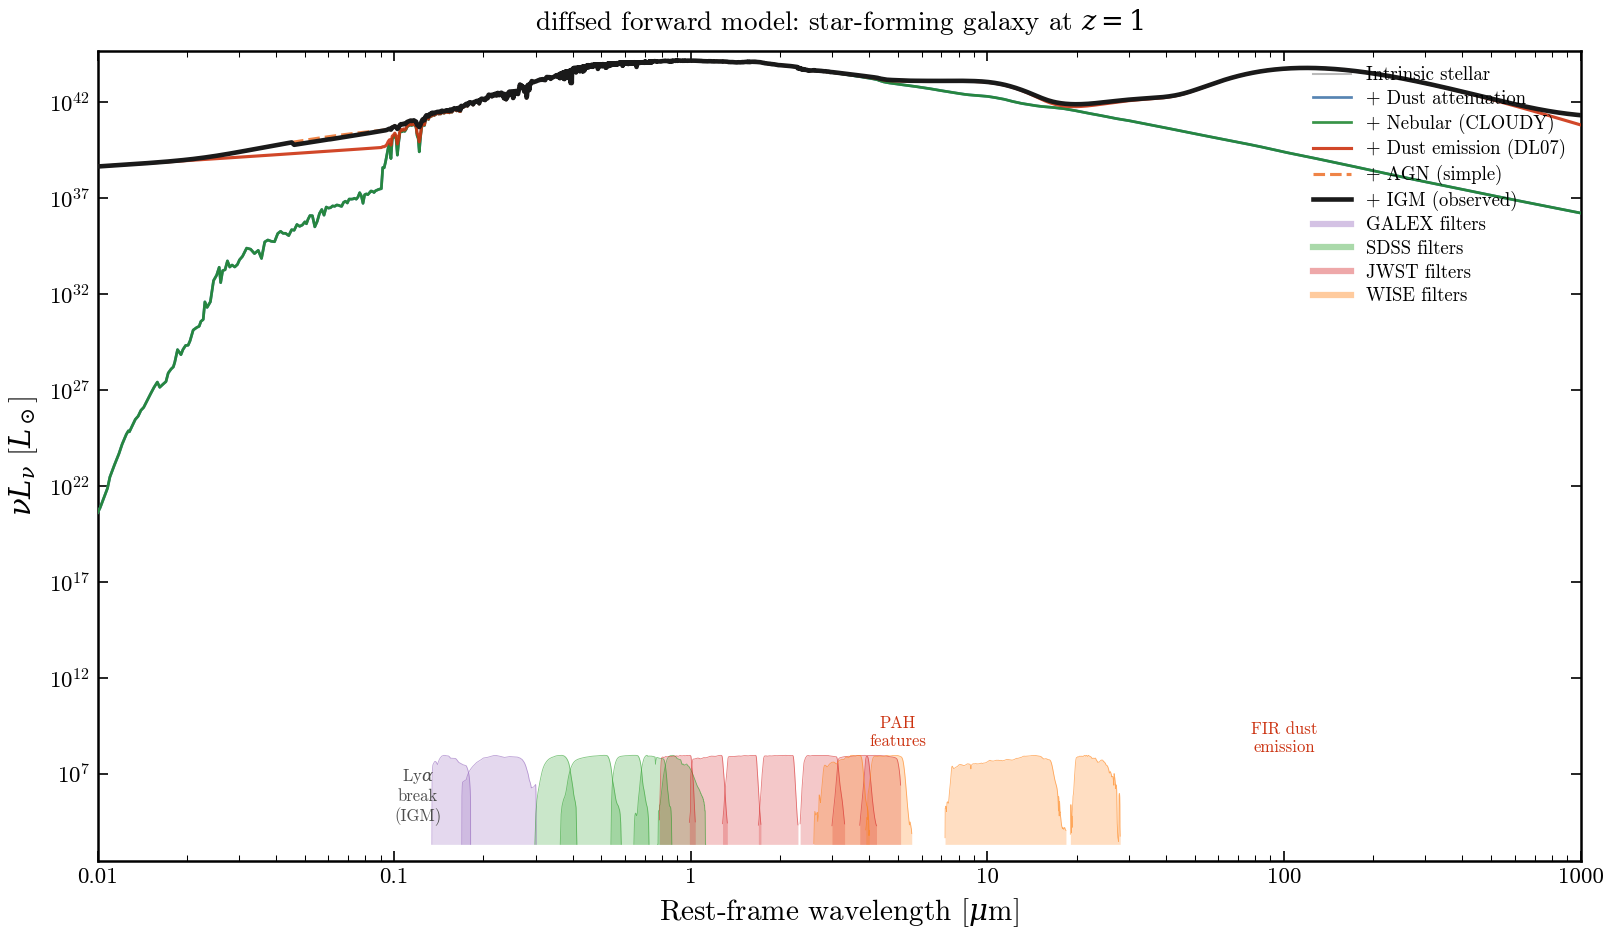

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.5))

# Component styles: (data, color, linestyle, linewidth, alpha, label)
components = [
    (nuLnu_intrinsic, "#aaaaaa",   "-",  1.0, 0.8, "Intrinsic stellar"),
    (nuLnu_dust,      "#4477aa",   "-",  1.3, 0.9, "+ Dust attenuation"),
    (nuLnu_neb,       "#228833",   "-",  1.3, 0.9, "+ Nebular (CLOUDY)"),
    (nuLnu_ir,        "#cc3311",   "-",  1.5, 0.9, "+ Dust emission (DL07)"),
    (nuLnu_agn,       "#ee7733",   "--", 1.5, 0.9, "+ AGN (simple)"),
    (nuLnu_final,     "#1a1a1a",   "-",  2.2, 1.0, "+ IGM (observed)"),
]

for data, color, ls, lw, alpha, label in components:
    # Clip very small values for log plot
    mask = data > 0
    ax.plot(wave_um_ssp[mask], data[mask], color=color, ls=ls, lw=lw,
            alpha=alpha, label=label, zorder=3)

# Overlay filter transmission curves at bottom
if filter_curves_fig1:
    ylim_bot = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e3
    # Color-code by survey
    survey_colors = {
        "galex": "#9467bd",
        "sdss": "#2ca02c",
        "jwst": "#d62728",
        "wise": "#ff7f0e",
    }

    # Get data range for filter placement
    ax.set_yscale("log")
    ax.set_xscale("log")

    # Determine filter y-placement: use bottom 15% of log range
    y_data_min = 1e3
    y_data_max = np.nanmax(nuLnu_ir[nuLnu_ir > 0]) * 3
    ax.set_ylim(y_data_min * 0.3, y_data_max)

    log_ymin = np.log10(y_data_min * 0.3)
    log_ymax = np.log10(y_data_max)
    filt_base = 10**(log_ymin + 0.02 * (log_ymax - log_ymin))
    filt_top = 10**(log_ymin + 0.13 * (log_ymax - log_ymin))

    for fc in filter_curves_fig1:
        # Determine survey from name
        survey = fc.name.split("_")[0]
        color = survey_colors.get(survey, "#7f7f7f")

        fw_um = np.array(fc.wave) / 1e4  # Angstrom -> micron
        ft = np.array(fc.trans)
        ft_norm = ft / ft.max()

        # Scale transmission to fill the designated y-band
        ft_scaled = filt_base + ft_norm * (filt_top - filt_base)
        ax.fill_between(fw_um, filt_base, ft_scaled, alpha=0.25,
                         color=color, lw=0, rasterized=True)
        ax.plot(fw_um, ft_scaled, color=color, lw=0.4, alpha=0.6)

    # Survey labels
    for survey, color in survey_colors.items():
        ax.plot([], [], color=color, lw=3, alpha=0.4,
                label=survey.upper() + " filters")

# Formatting
ax.set_xlabel(r"Rest-frame wavelength [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [$L_\odot$]")
ax.set_xlim(0.01, 1000)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels(["0.01", "0.1", "1", "10", "100", "1000"])

# Text labels for key physics (no arrows to avoid None-coordinate issues)
ax.text(0.12, 2e4, r"Ly$\alpha$" + "\nbreak\n(IGM)",
        fontsize=8, color="0.3", ha="center", va="bottom")
ax.text(5.0, 2e8, "PAH\nfeatures",
        fontsize=8, color="#cc3311", ha="center", va="bottom")
ax.text(100, 1e8, "FIR dust\nemission",
        fontsize=8, color="#cc3311", ha="center", va="bottom")

ax.legend(loc="upper right", fontsize=9, ncol=1, handlelength=2.0)
ax.set_title(r"diffsed forward model: star-forming galaxy at $z=1$",
             fontsize=13, pad=10)

fig.tight_layout()
savefig(fig, "forward_model_pipeline")
plt.show()

---
## Figure 2: Dust Attenuation Curve Comparison

All 7 attenuation curves normalized at $V$-band (5500 \AA),
plotted on a log-wavelength $x$-axis from 0.1 to 3 $\mu$m.
An inset zooms into the 2175 \AA\ UV bump region.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_83483/1272142566.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figures/18_dust_attenuation_curves.png and .pdf


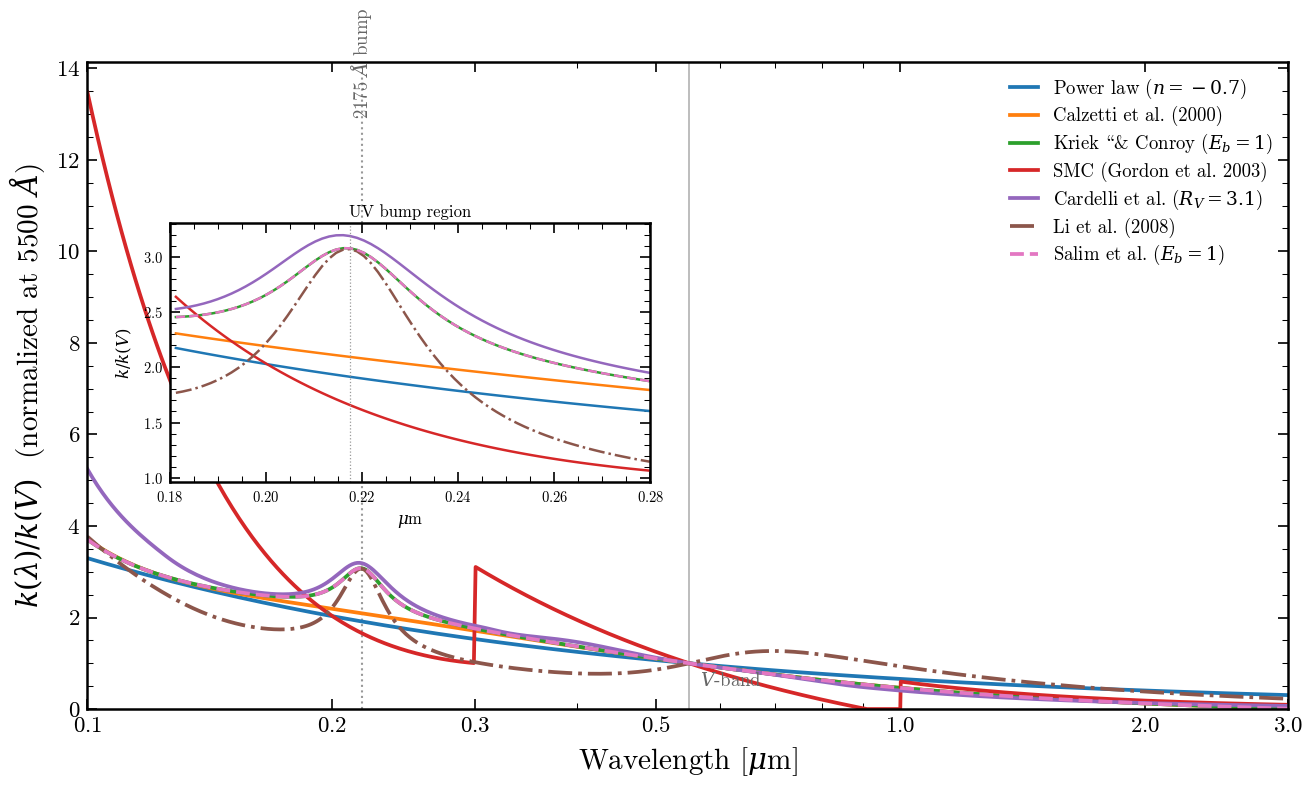

In [7]:
wave_aa = jnp.linspace(1000.0, 30000.0, 2000)

# Evaluate each curve
curves = {}
for name, fn in DUST_LAWS.items():
    if name in ("kriek_conroy", "salim"):
        curves[name] = fn(wave_aa, dust_bump_strength=1.0, dust_delta=0.0)
    elif name == "power_law":
        curves[name] = fn(wave_aa, n_slope=-0.7)
    elif name == "cardelli":
        curves[name] = fn(wave_aa, dust_Rv=3.1)
    elif name == "li08":
        curves[name] = fn(wave_aa, dust_UV_slope=-1.0, dust_OPT_slope=-1.3,
                           dust_FUV_slope=-1.8, dust_bump_strength=1.0)
    else:
        curves[name] = fn(wave_aa)

# Normalize at V-band
wave_arr = np.array(wave_aa)
v_idx = np.argmin(np.abs(wave_arr - 5500.0))
curves_norm = {}
for name, k in curves.items():
    k_arr = np.array(k)
    k_at_v = k_arr[v_idx]
    curves_norm[name] = k_arr / k_at_v if k_at_v > 0 else k_arr

# Style definitions
curve_styles = {
    "power_law":     ("#1f77b4", "-",  1.8, r"Power law ($n=-0.7$)"),
    "calzetti":      ("#ff7f0e", "-",  1.8, "Calzetti et al. (2000)"),
    "kriek_conroy":  ("#2ca02c", "-",  1.8, r"Kriek \& Conroy ($E_b=1$)"),
    "smc":           ("#d62728", "-",  1.8, "SMC (Gordon et al. 2003)"),
    "cardelli":      ("#9467bd", "-",  1.8, r"Cardelli et al. ($R_V=3.1$)"),
    "salim":         ("#e377c2", "--", 1.8, r"Salim et al. ($E_b=1$)"),
    "li08":          ("#8c564b", "-.", 1.8, "Li et al. (2008)"),
}

wave_um = wave_arr / 1e4

fig, ax = plt.subplots(figsize=(9, 5.5))

for name in DUST_LAWS:
    if name not in curve_styles:
        continue
    color, ls, lw, label = curve_styles[name]
    ax.plot(wave_um, curves_norm[name], color=color, ls=ls, lw=lw, label=label)

# V-band reference
ax.axvline(0.55, color="0.4", ls="-", lw=0.8, zorder=0, alpha=0.5)
ax.annotate(r"$V$-band", xy=(0.55, 0.03), xycoords=("data", "axes fraction"),
            fontsize=9, color="0.4", ha="left", va="bottom",
            xytext=(5, 0), textcoords="offset points")

# 2175 A UV bump annotation
ax.axvline(0.2175, color="0.6", ls=":", lw=1.0, zorder=0)
ax.annotate(r"2175 $\AA$ bump", xy=(0.2175, 0.92),
            xycoords=("data", "axes fraction"),
            fontsize=9, color="0.4", ha="center", rotation=90)

ax.set_xscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$k(\lambda) / k(V)$  (normalized at 5500 $\AA$)")
ax.set_xlim(0.1, 3.0)
ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xticks([0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 3.0])
ax.legend(loc="upper right", fontsize=9, ncol=1)

# --- Inset: UV bump region (1800--2600 A) ---
ax_inset = inset_axes(ax, width="40%", height="40%", loc="center left",
                       bbox_to_anchor=(0.06, 0.05, 1, 1),
                       bbox_transform=ax.transAxes)
bump_mask = (wave_arr >= 1800) & (wave_arr <= 2800)
for name in DUST_LAWS:
    if name not in curve_styles:
        continue
    color, ls, lw, label = curve_styles[name]
    ax_inset.plot(wave_arr[bump_mask] / 1e4, curves_norm[name][bump_mask],
                   color=color, ls=ls, lw=1.2)

ax_inset.set_xlim(0.18, 0.28)
ax_inset.set_xlabel(r"$\mu$m", fontsize=8)
ax_inset.set_ylabel(r"$k/k(V)$", fontsize=8)
ax_inset.tick_params(labelsize=7)
ax_inset.set_title("UV bump region", fontsize=8, pad=3)
ax_inset.axvline(0.2175, color="0.6", ls=":", lw=0.6)

fig.tight_layout()
savefig(fig, "dust_attenuation_curves")
plt.show()

---
## Figure 3: AGN Model Zoo

All 6 AGN models evaluated at the same bolometric luminosity
($\log L_{\rm bol} = 44\,L_\odot$), showing the diversity of SED
shapes from the simple 3-parameter model to the full QSOgen empirical
template and SKIRTOR clumpy torus.

In [8]:
wave_agn = jnp.logspace(2, 6, 3000)  # 100 A to 100 um
nu_agn = 2.99792458e18 / np.array(wave_agn)
wave_agn_um = np.array(wave_agn) / 1e4

log_lbol = 44.0

# Model display styles
agn_styles = {
    "simple":          ("#2b6ca3", "-",   2.0, "simple (3 params)"),
    "standard":        ("#d65f27", "--",  2.0, "standard (SS73 disc + 2T torus)"),
    "kubota_done":     ("#3a9a5b", ":",   2.2, "kubota\\_done (physical disc)"),
    "unified_nlr_blr": ("#c03d3e", "-.",  2.0, "unified\\_nlr\\_blr (NLR/BLR)"),
    "qsogen":          ("#8b6bba", "-",   2.5, "qsogen (Temple+2021)"),
    "skirtor":         ("#8c564b", "-",   2.0, "skirtor (Stalevski+2016)"),
}

# Compute all AGN SEDs
agn_seds = {}
for name in sorted(AGN_MODELS.keys()):
    try:
        agn_seds[name] = np.array(
            AGN_MODELS[name](wave_agn, agn_log_lbol=log_lbol, agn_lum_ratio=1.0)
        )
    except (FileNotFoundError, Exception) as e:
        print(f"Skipping {name}: {e}")
        continue

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_83483/604783578.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved figures/18_agn_model_zoo.png and .pdf


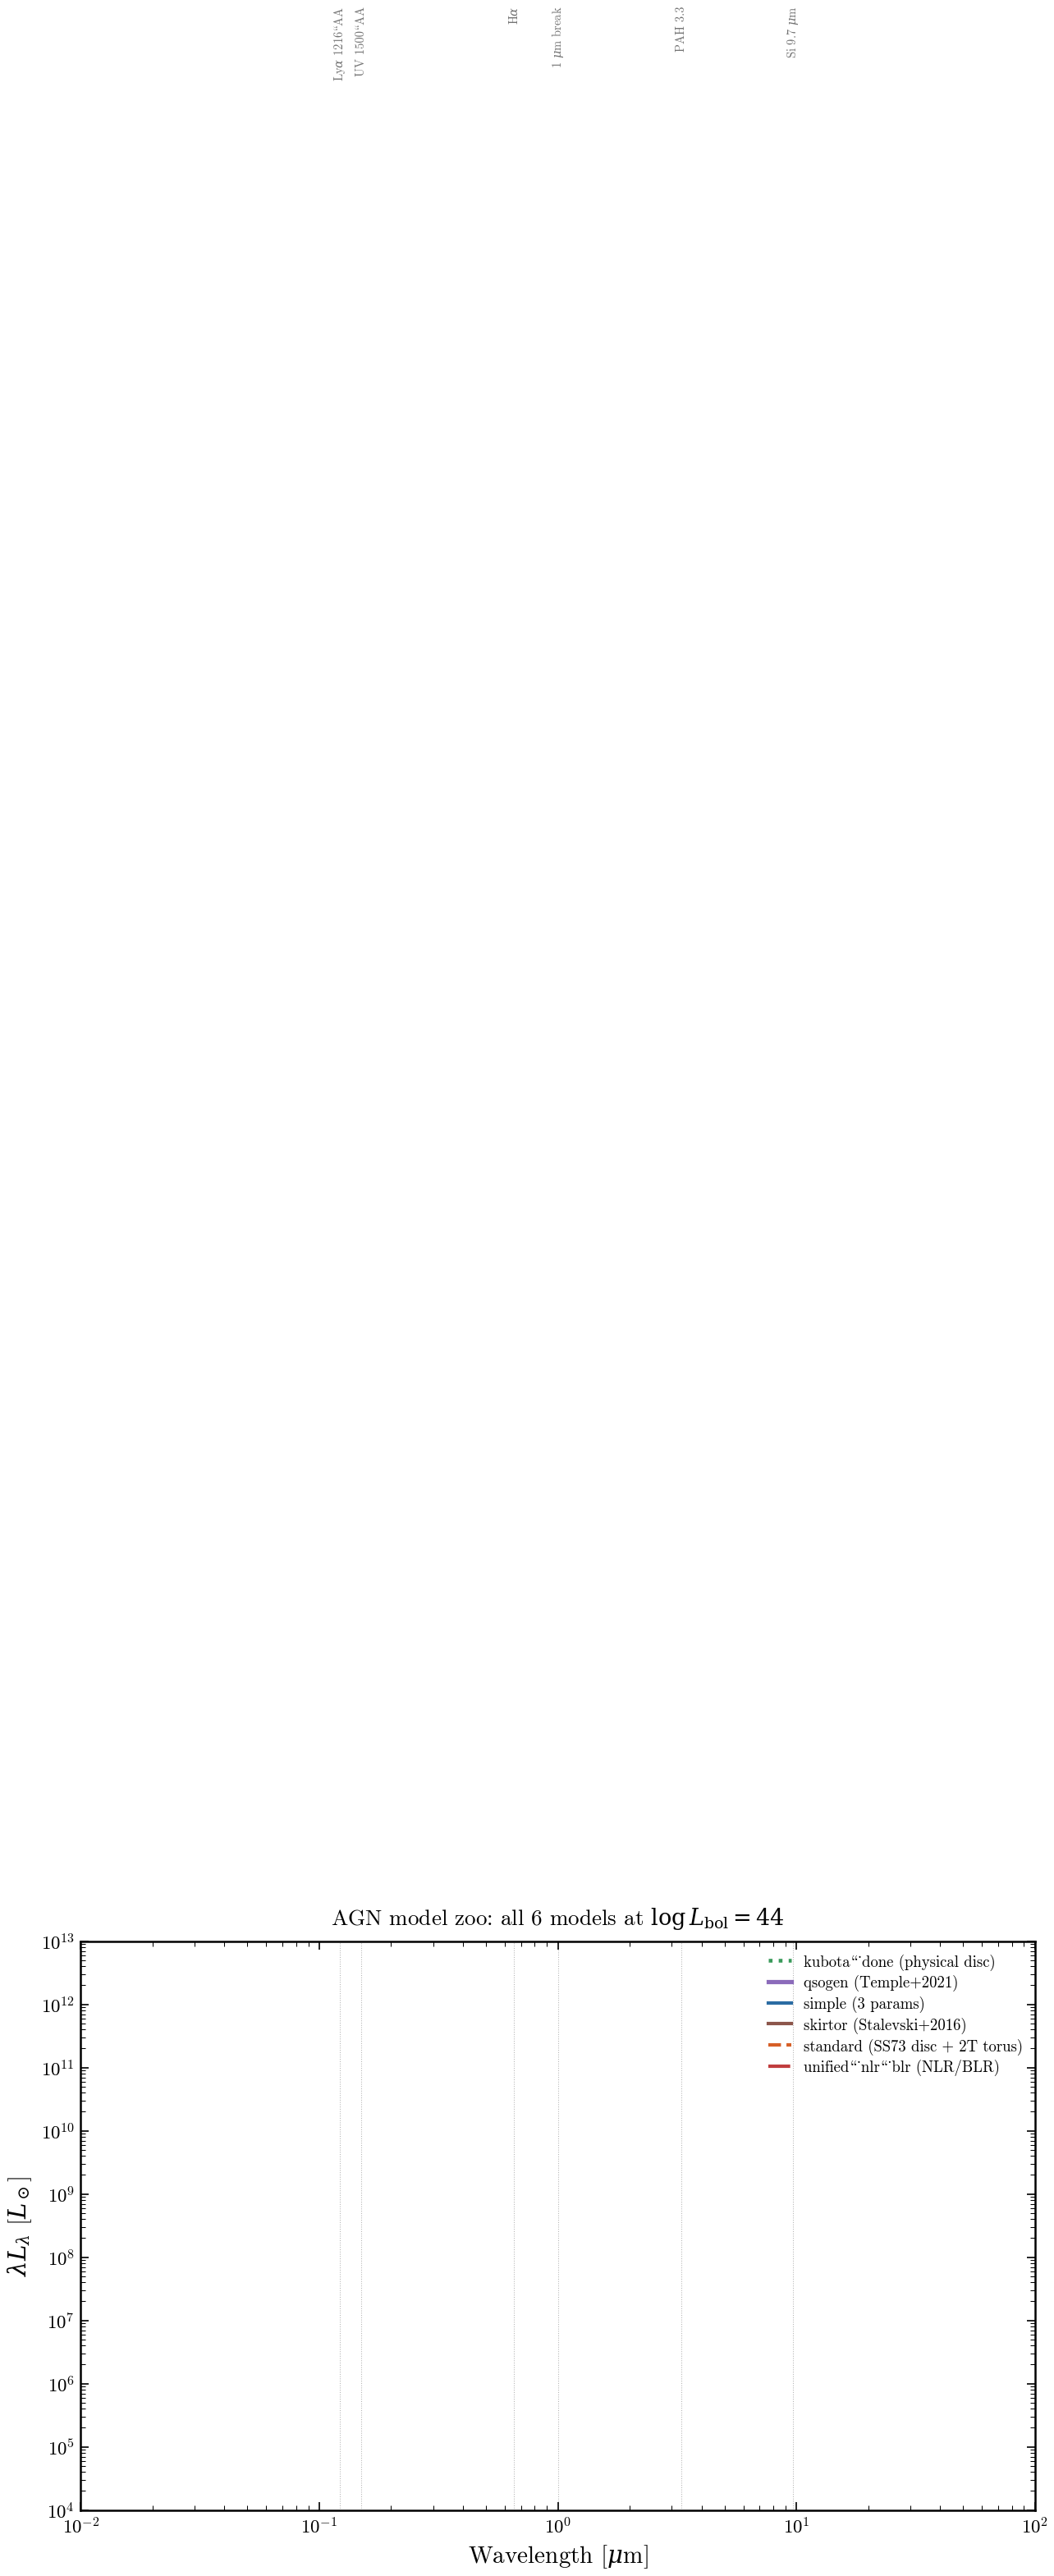

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for name in sorted(agn_seds.keys()):
    if name not in agn_styles:
        continue
    color, ls, lw, label = agn_styles[name]
    lLl = agn_seds[name] * nu_agn
    mask = lLl > 0
    ax.loglog(wave_agn_um[mask], lLl[mask], color=color, ls=ls, lw=lw,
              label=label)

# Key wavelength annotations
key_features = {
    r"Ly$\alpha$ 1216\AA": 0.1216,
    r"UV 1500\AA": 0.15,
    r"H$\alpha$": 0.6563,
    r"1 $\mu$m break": 1.0,
    r"Si 9.7 $\mu$m": 9.7,
    r"PAH 3.3": 3.3,
}
ylim_top = ax.get_ylim()[1]
for label, lam_um in key_features.items():
    ax.axvline(lam_um, color="0.7", ls=":", lw=0.5, zorder=0)
    ax.text(lam_um, ylim_top * 0.3, label, fontsize=7, color="0.45",
            ha="center", va="top", rotation=90, style="italic")

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\lambda L_\lambda$ [$L_\odot$]")
ax.set_xlim(0.01, 100)
ax.set_ylim(1e4, 1e13)
ax.legend(loc="upper right", fontsize=9, ncol=1)
ax.set_title(r"AGN model zoo: all 6 models at $\log L_{\rm bol} = 44$",
             fontsize=13, pad=10)

fig.tight_layout()
savefig(fig, "agn_model_zoo")
plt.show()

---
## Figure 4: Parameter Degeneracies

A 2$\times$2 panel showing four classic SED-fitting degeneracies.
For each panel we generate 2--3 SEDs with very different physical
properties but nearly identical broadband photometry, illustrating
why these degeneracies are challenging for SED fitting codes.

In [10]:
# Load filters for photometry comparison
filter_names_phot = [
    "galex_fuv", "galex_nuv",
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "2mass_j", "2mass_h", "2mass_ks",
    "wise_w1", "wise_w2",
]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    filters_phot = load_filter_set(filter_names_phot)


# Helper: build a parametric model and compute SED + photometry
def make_model_and_sed(spec_kwargs, with_filters=True):
    """Build model with given spec kwargs, return SED + photometry."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spec = ParamSpec(**spec_kwargs)
        filt = filters_phot if with_filters else None
        model = Model(spec, ssp, filters=filt, precompute=False, approx=False)
        params = spec.sample(jax.random.PRNGKey(0))
        sed = np.array(model.predict_sed(params))
        phot = np.array(model.predict_photometry(params)) if with_filters else None
    return sed, phot, wave_rest, model

In [11]:
# Panel (a): Age-Dust degeneracy
# Young+dusty vs Old+clean
_common_a = dict(
    mean_sfh_type="dpl",
    met_logzsol=Fixed(-0.3),
    redshift=Fixed(0.5),
    apply_igm=False,
)

# Young, dusty galaxy
sed_young, phot_young, _, _ = make_model_and_sed(dict(
    **_common_a,
    sfh_dpl_alpha=Fixed(1.0), sfh_dpl_beta=Fixed(2.0),
    sfh_dpl_tau_gyr=Fixed(2.0), sfh_dpl_log_peak_sfr=Fixed(1.5),
    dust_tau_bc=Fixed(1.2), dust_tau_diff=Fixed(0.8),
))

# Old, clean galaxy (adjust SFR normalization to match flux roughly)
sed_old, phot_old, _, _ = make_model_and_sed(dict(
    **_common_a,
    sfh_dpl_alpha=Fixed(1.5), sfh_dpl_beta=Fixed(1.0),
    sfh_dpl_tau_gyr=Fixed(8.0), sfh_dpl_log_peak_sfr=Fixed(1.8),
    dust_tau_bc=Fixed(0.1), dust_tau_diff=Fixed(0.05),
))

In [12]:
# Panel (b): AGN-Dust degeneracy
# AGN UV excess vs reduced dust
_common_b = dict(
    mean_sfh_type="dpl",
    sfh_dpl_alpha=Fixed(1.2), sfh_dpl_beta=Fixed(1.5),
    sfh_dpl_tau_gyr=Fixed(4.0), sfh_dpl_log_peak_sfr=Fixed(1.5),
    met_logzsol=Fixed(-0.3),
    redshift=Fixed(0.5),
    apply_igm=False,
)

sed_dusty_noagn, phot_dusty_noagn, _, _ = make_model_and_sed(dict(
    **_common_b,
    dust_tau_bc=Fixed(0.8), dust_tau_diff=Fixed(0.5),
))

sed_agn_lessdust, phot_agn_lessdust, _, _ = make_model_and_sed(dict(
    **_common_b,
    dust_tau_bc=Fixed(0.3), dust_tau_diff=Fixed(0.15),
    agn_model="simple", agn_lum_ratio=Fixed(0.15),
))

In [13]:
# Panel (c): Z-Age degeneracy
# Metal-rich young vs metal-poor old
_common_c = dict(
    mean_sfh_type="dpl",
    dust_tau_bc=Fixed(0.2), dust_tau_diff=Fixed(0.1),
    redshift=Fixed(0.3),
    apply_igm=False,
)

sed_Zrich_young, phot_Zrich_young, _, _ = make_model_and_sed(dict(
    **_common_c,
    sfh_dpl_alpha=Fixed(1.0), sfh_dpl_beta=Fixed(2.0),
    sfh_dpl_tau_gyr=Fixed(2.5), sfh_dpl_log_peak_sfr=Fixed(1.3),
    met_logzsol=Fixed(0.1),
))

sed_Zpoor_old, phot_Zpoor_old, _, _ = make_model_and_sed(dict(
    **_common_c,
    sfh_dpl_alpha=Fixed(1.5), sfh_dpl_beta=Fixed(0.8),
    sfh_dpl_tau_gyr=Fixed(9.0), sfh_dpl_log_peak_sfr=Fixed(1.7),
    met_logzsol=Fixed(-1.0),
))

In [14]:
# Panel (d): AGN-SFR degeneracy (MIR)
# AGN torus MIR emission vs high-SFR dust emission
_common_d = dict(
    mean_sfh_type="dpl",
    met_logzsol=Fixed(-0.3),
    dust_tau_bc=Fixed(0.5), dust_tau_diff=Fixed(0.3),
    redshift=Fixed(0.5),
    apply_igm=False,
)

# High SFR with dust emission
sed_highsfr, phot_highsfr, _, _ = make_model_and_sed(dict(
    **_common_d,
    sfh_dpl_alpha=Fixed(1.0), sfh_dpl_beta=Fixed(2.0),
    sfh_dpl_tau_gyr=Fixed(2.0), sfh_dpl_log_peak_sfr=Fixed(2.0),
    dust_emission="draine_li2007",
    dust_umin=Fixed(2.0), dust_gamma_dl=Fixed(0.02), dust_qpah=Fixed(3.0),
))

# Lower SFR with AGN
sed_agn_lowsfr, phot_agn_lowsfr, _, _ = make_model_and_sed(dict(
    **_common_d,
    sfh_dpl_alpha=Fixed(1.2), sfh_dpl_beta=Fixed(1.5),
    sfh_dpl_tau_gyr=Fixed(5.0), sfh_dpl_log_peak_sfr=Fixed(1.3),
    dust_emission="draine_li2007",
    dust_umin=Fixed(2.0), dust_gamma_dl=Fixed(0.02), dust_qpah=Fixed(3.0),
    agn_model="simple", agn_lum_ratio=Fixed(0.2),
))

Saved figures/18_parameter_degeneracies.png and .pdf


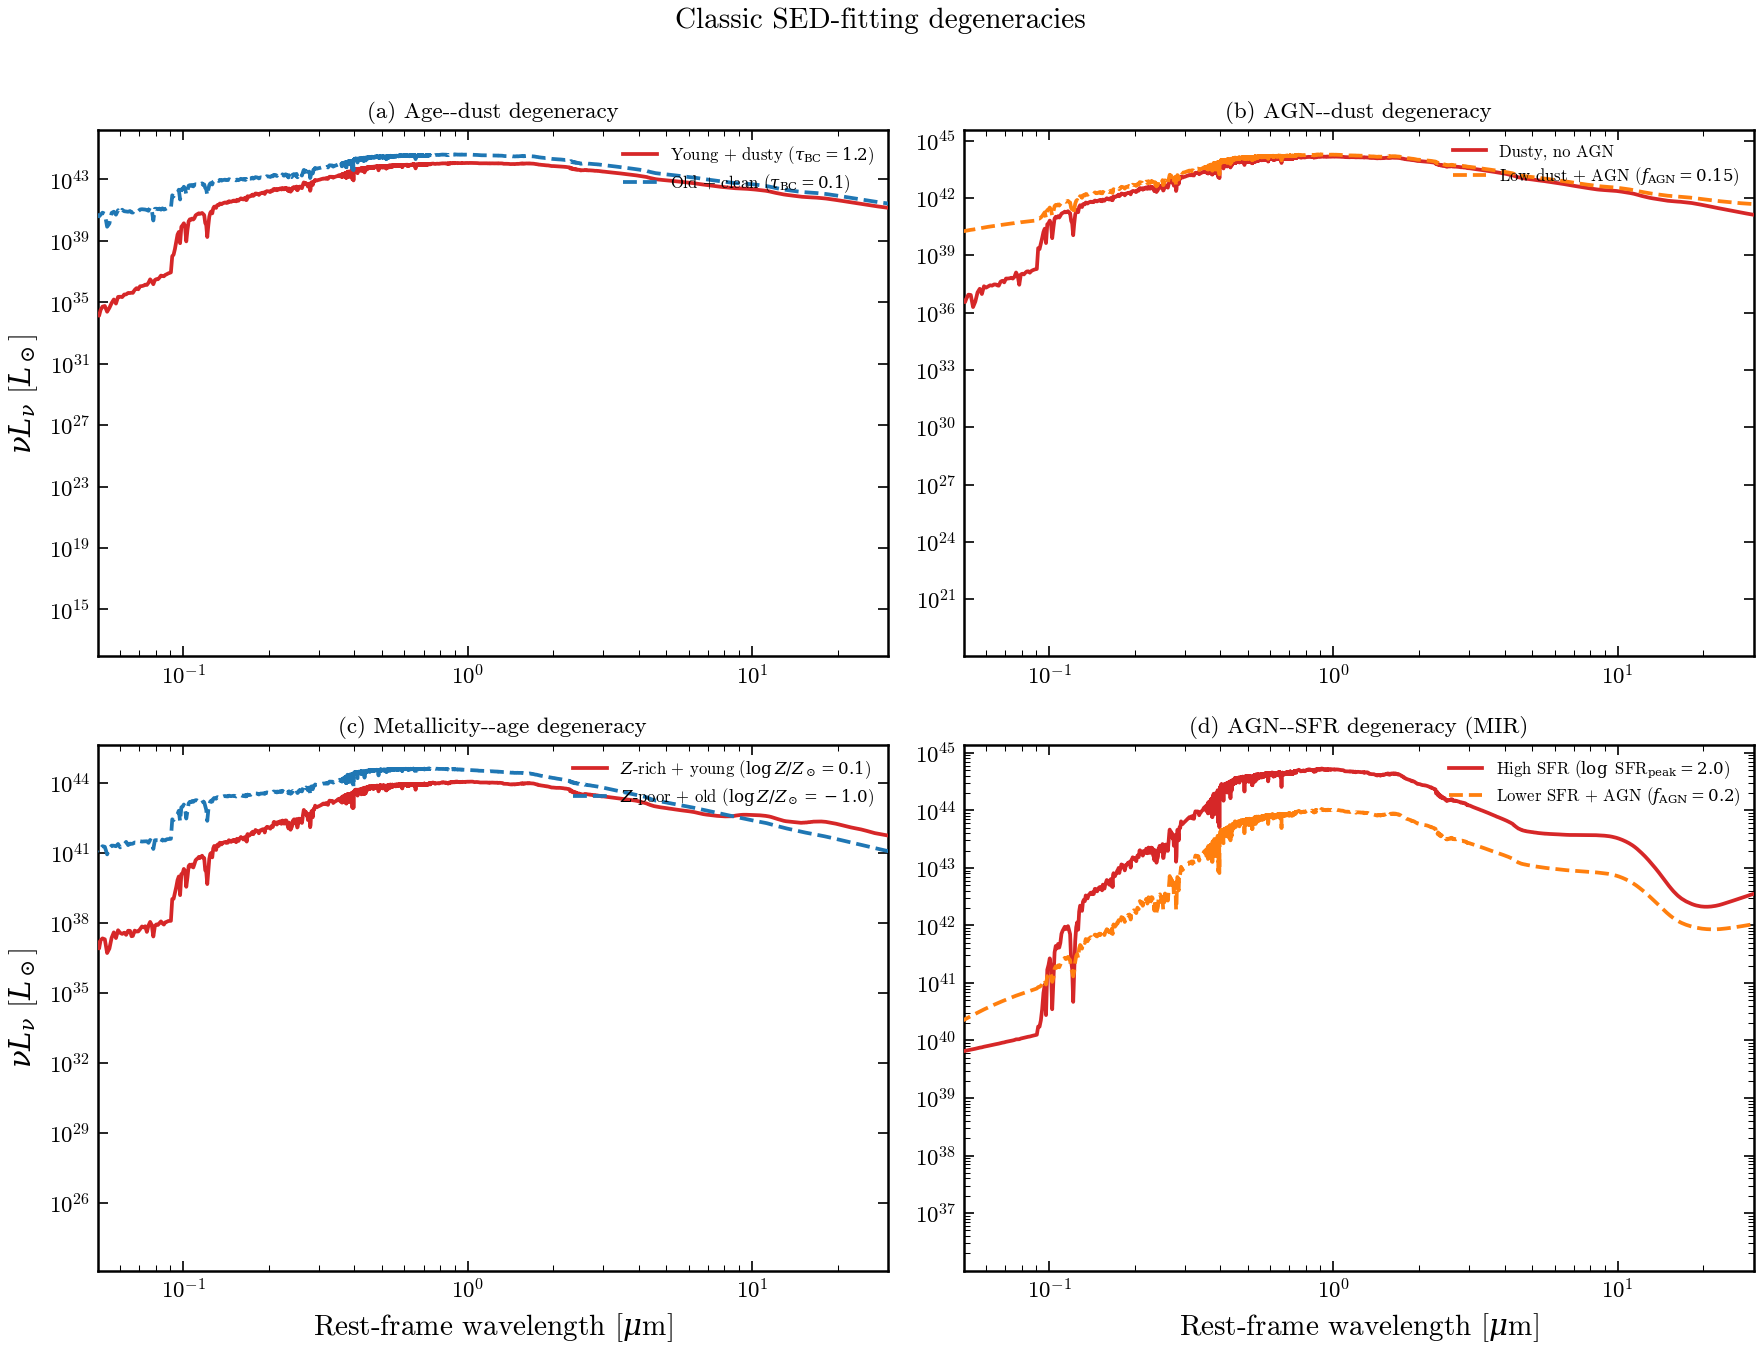

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Helper to plot SED comparison
def plot_degeneracy(ax, seds_info, title, xlabel=True, ylabel=True):
    """Plot multiple SEDs on one axis.

    seds_info: list of (sed_array, color, ls, lw, label)
    """
    for sed, color, ls, lw, label in seds_info:
        nuLnu = sed * nu_ssp
        mask = nuLnu > 0
        ax.loglog(wave_um_ssp[mask], nuLnu[mask], color=color, ls=ls, lw=lw,
                  label=label, zorder=3)

    ax.set_xlim(0.05, 30)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.legend(loc="upper right", fontsize=8, handlelength=2.0)

    if xlabel:
        ax.set_xlabel(r"Rest-frame wavelength [$\mu$m]")
    if ylabel:
        ax.set_ylabel(r"$\nu L_\nu$ [$L_\odot$]")


# (a) Age-Dust
plot_degeneracy(axes[0, 0], [
    (sed_young, "#d62728", "-", 1.8, r"Young + dusty ($\tau_{\rm BC}=1.2$)"),
    (sed_old,   "#1f77b4", "--", 1.8, r"Old + clean ($\tau_{\rm BC}=0.1$)"),
], "(a) Age--dust degeneracy", xlabel=False)

# (b) AGN-Dust
plot_degeneracy(axes[0, 1], [
    (sed_dusty_noagn,   "#d62728", "-", 1.8, r"Dusty, no AGN"),
    (sed_agn_lessdust,  "#ff7f0e", "--", 1.8, r"Low dust + AGN ($f_{\rm AGN}=0.15$)"),
], "(b) AGN--dust degeneracy", xlabel=False, ylabel=False)

# (c) Z-Age
plot_degeneracy(axes[1, 0], [
    (sed_Zrich_young, "#d62728", "-", 1.8, r"$Z$-rich + young ($\log Z/Z_\odot = 0.1$)"),
    (sed_Zpoor_old,   "#1f77b4", "--", 1.8, r"$Z$-poor + old ($\log Z/Z_\odot = -1.0$)"),
], r"(c) Metallicity--age degeneracy")

# (d) AGN-SFR
plot_degeneracy(axes[1, 1], [
    (sed_highsfr,    "#d62728", "-", 1.8, r"High SFR ($\log$ SFR$_{\rm peak}=2.0$)"),
    (sed_agn_lowsfr, "#ff7f0e", "--", 1.8, r"Lower SFR + AGN ($f_{\rm AGN}=0.2$)"),
], "(d) AGN--SFR degeneracy (MIR)", ylabel=False)

fig.suptitle("Classic SED-fitting degeneracies", fontsize=14, y=1.01)
fig.tight_layout()
savefig(fig, "parameter_degeneracies")
plt.show()

---
## Figure 5: Wavelength Coverage

A complete galaxy+AGN SED from X-ray (0.1 \AA) to radio (10 cm),
with all physical components labeled. This shows the full panchromatic
reach of **diffsed** when all modules (radio, X-ray) are enabled.

In [16]:
# Build the most complete model: stellar + dust + nebular + AGN + radio + xray
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    spec_panchro = ParamSpec(
        mean_sfh_type="dpl",
        sfh_dpl_alpha=Fixed(1.2), sfh_dpl_beta=Fixed(1.5),
        sfh_dpl_tau_gyr=Fixed(4.0), sfh_dpl_log_peak_sfr=Fixed(1.8),
        met_logzsol=Fixed(-0.3),
        dust_tau_bc=Fixed(0.6), dust_tau_diff=Fixed(0.3),
        cloudy_grid_path=CLOUDY_PATH,
        neb_logU=Fixed(-2.5),
        dust_emission="draine_li2007",
        dust_umin=Fixed(2.0), dust_gamma_dl=Fixed(0.02), dust_qpah=Fixed(3.0),
        agn_model="simple", agn_lum_ratio=Fixed(0.15),
        radio=True,
        xray=True,
        redshift=Fixed(0.5),
        apply_igm=False,
    )
    model_panchro = Model(spec_panchro, ssp, precompute=False, approx=False)

params_panchro = spec_panchro.sample(jax.random.PRNGKey(123))
sed_panchro = np.array(model_panchro.predict_sed(params_panchro))

# Also get individual components for labeling
# Stellar only
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    spec_stellar = ParamSpec(
        mean_sfh_type="dpl",
        sfh_dpl_alpha=Fixed(1.2), sfh_dpl_beta=Fixed(1.5),
        sfh_dpl_tau_gyr=Fixed(4.0), sfh_dpl_log_peak_sfr=Fixed(1.8),
        met_logzsol=Fixed(-0.3),
        dust_tau_bc=Fixed(0.0), dust_tau_diff=Fixed(0.0),
        redshift=Fixed(0.5),
        apply_igm=False,
    )
    model_stellar = Model(spec_stellar, ssp, precompute=False, approx=False)
    sed_stellar_only = np.array(model_stellar.predict_sed(
        spec_stellar.sample(jax.random.PRNGKey(123))))

<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['agn_cos_inc', 'agn_oa_skirtor', 'agn_p_skirtor', 'agn_q_skirtor', 'agn_tau_skirtor', 'dust_alpha_dl14']. These will be silently ignored. Did you mean one of: ['agn_T_torus', 'agn_alpha', 'agn_lum_ratio', 'agn_log_lbol', 'agn_log_ledd', 'agn_log_mbh', 'agn_tau_torus', 'agn_torus_frac', 'dust_Rv', 'dust_T', 'dust_alpha_dale', 'dust_alpha_mir', 'dust_beta_ir', 'dust_bump_strength', 'dust_delta', 'dust_eta_balance', 'dust_f_obscuration', 'dust_gamma_dl', 'dust_qpah', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'dust_umin', 'met_alpha_fe', 'met_logzsol', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_logZ_gas', 'noise_dof', 'noise_frac_cal', 'radio_alpha_agn', 'radio_alpha_sf', 'radio_loudness', 'radio_q_ir', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr', 'xray_alpha_ox', 'xray_gamma_agn']?
  return self._compute_sed_components(params)["se

Saved figures/18_wavelength_coverage.png and .pdf


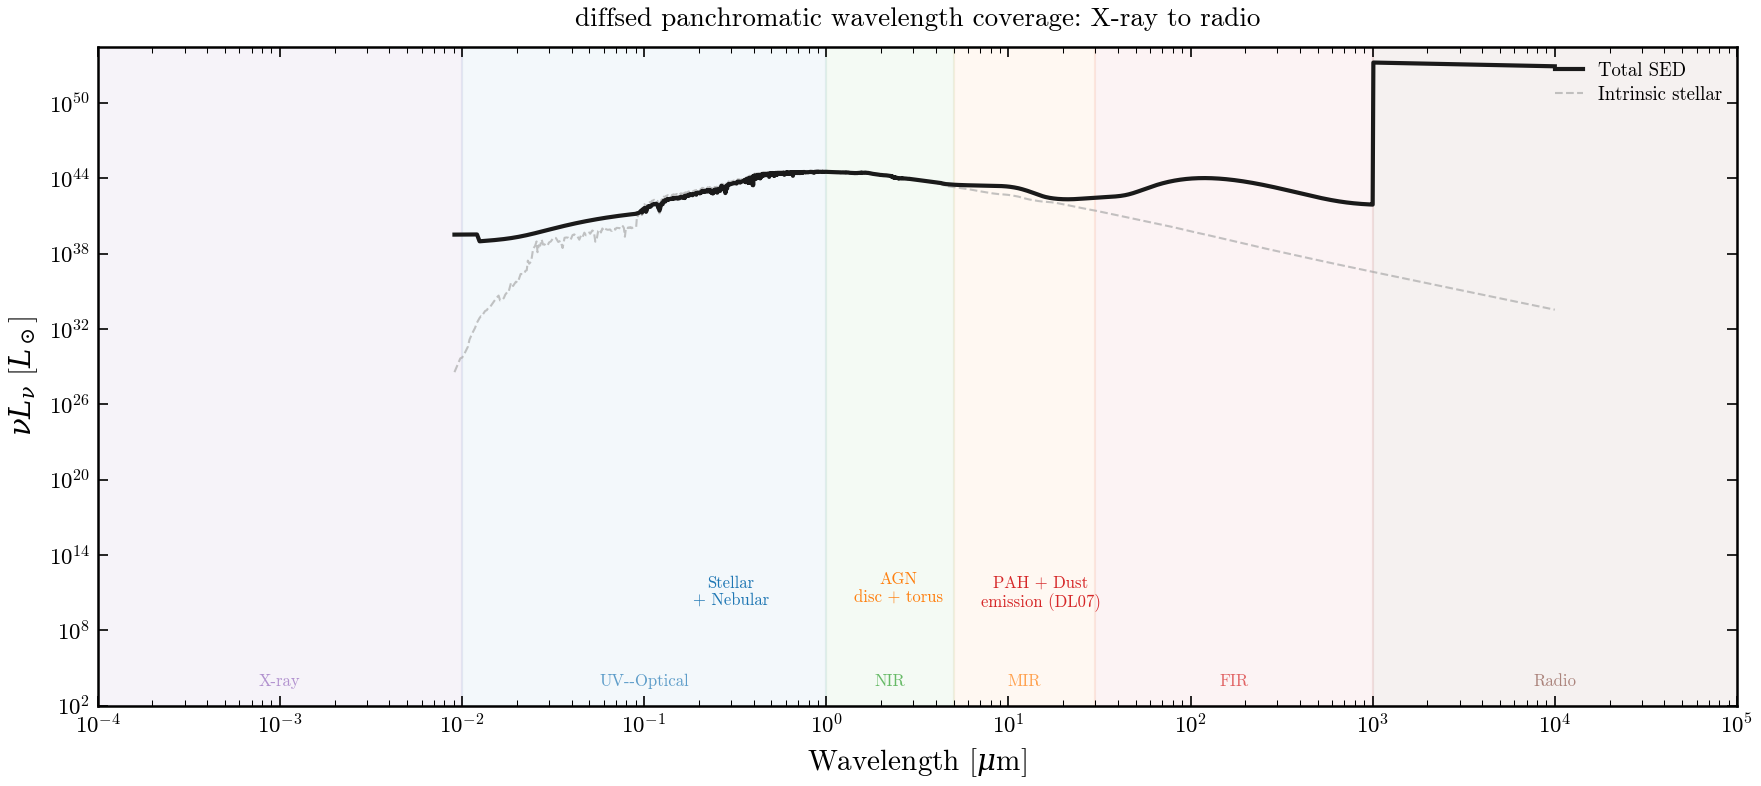

In [17]:
# Convert to nu*L_nu
nuLnu_panchro = sed_panchro * nu_ssp
nuLnu_stellar_only = sed_stellar_only * nu_ssp

fig, ax = plt.subplots(figsize=(12, 5.5))

# Total SED
mask_total = nuLnu_panchro > 0
ax.loglog(wave_um_ssp[mask_total], nuLnu_panchro[mask_total],
          color="#1a1a1a", lw=2.0, label="Total SED", zorder=5)

# Intrinsic stellar
mask_star = nuLnu_stellar_only > 0
ax.loglog(wave_um_ssp[mask_star], nuLnu_stellar_only[mask_star],
          color="#aaaaaa", lw=1.0, ls="--", alpha=0.7,
          label="Intrinsic stellar", zorder=2)

# Wavelength regime shading
regime_colors = {
    "X-ray":      ((1e-4, 0.01),  "#9467bd", 0.08),
    "UV--Optical":((0.01, 1.0),   "#1f77b4", 0.05),
    "NIR":        ((1.0, 5.0),    "#2ca02c", 0.05),
    "MIR":        ((5.0, 30.0),   "#ff7f0e", 0.05),
    "FIR":        ((30.0, 1000.0),   "#d62728", 0.05),
    "Radio":      ((1000.0, 1e5), "#8c564b", 0.08),
}

for regime, ((lo, hi), color, alpha) in regime_colors.items():
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0)
    # Place label at geometric center
    center = np.sqrt(lo * hi)
    ylim = ax.get_ylim()
    ax.text(center, 2e3, regime, fontsize=8, ha="center", va="bottom",
            color=color, fontweight="bold", alpha=0.7, zorder=1)

# Component text labels
ax.text(0.3, 5e9, "Stellar\n+ Nebular", fontsize=8, color="#1f77b4",
        ha="center", va="bottom")
ax.text(15, 3e9, "PAH + Dust\nemission (DL07)", fontsize=8,
        color="#d62728", ha="center", va="bottom")
ax.text(2.5, 1e10, "AGN\ndisc + torus", fontsize=8, color="#ff7f0e",
        ha="center", va="bottom")

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [$L_\odot$]")
ax.set_xlim(1e-4, 1e5)
ax.set_ylim(1e2, None)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("diffsed panchromatic wavelength coverage: X-ray to radio",
             fontsize=13, pad=10)

fig.tight_layout()
savefig(fig, "wavelength_coverage")
plt.show()

---
## Figure 6: Filter Library

All major filter sets available in **diffsed** overlaid on a template
galaxy SED.  Filters are color-coded by survey/instrument.

In [18]:
# Define filter groups with colors
filter_groups = {
    "GALEX":     (["galex_fuv", "galex_nuv"], "#9467bd"),
    "SDSS":      (["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"], "#2ca02c"),
    "HST ACS":   (["hst_f435w", "hst_f606w", "hst_f775w", "hst_f814w"], "#1f77b4"),
    "HST WFC3":  (["hst_f105w", "hst_f125w", "hst_f140w", "hst_f160w"], "#17becf"),
    "JWST NIRCam": (["jwst_f090w", "jwst_f115w", "jwst_f150w", "jwst_f200w",
                     "jwst_f277w", "jwst_f356w", "jwst_f410m", "jwst_f444w"], "#d62728"),
    "WISE":      (["wise_w1", "wise_w2", "wise_w3", "wise_w4"], "#ff7f0e"),
    "2MASS":     (["2mass_j", "2mass_h", "2mass_ks"], "#8c564b"),
}

# Load all filters
loaded_groups = {}
for group_name, (names, color) in filter_groups.items():
    curves = []
    for fn in names:
        try:
            fc = load_filter(fn)
            curves.append(fc)
        except Exception as e:
            print(f"Skipping {fn}: {e}")
    loaded_groups[group_name] = (curves, color)

<local>/Projects/diffsed/src/diffsed/model.py:1331: UserWarning: Unrecognized parameter names passed to Model: ['dust_alpha_dl14']. These will be silently ignored. Did you mean one of: ['dust_Rv', 'dust_T', 'dust_alpha_dale', 'dust_alpha_mir', 'dust_beta_ir', 'dust_bump_strength', 'dust_delta', 'dust_eta_balance', 'dust_f_obscuration', 'dust_gamma_dl', 'dust_qpah', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'dust_umin', 'met_alpha_fe', 'met_logzsol', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']?
  return self._compute_sed_components(params)["sed_total"]


Saved figures/18_filter_library.png and .pdf


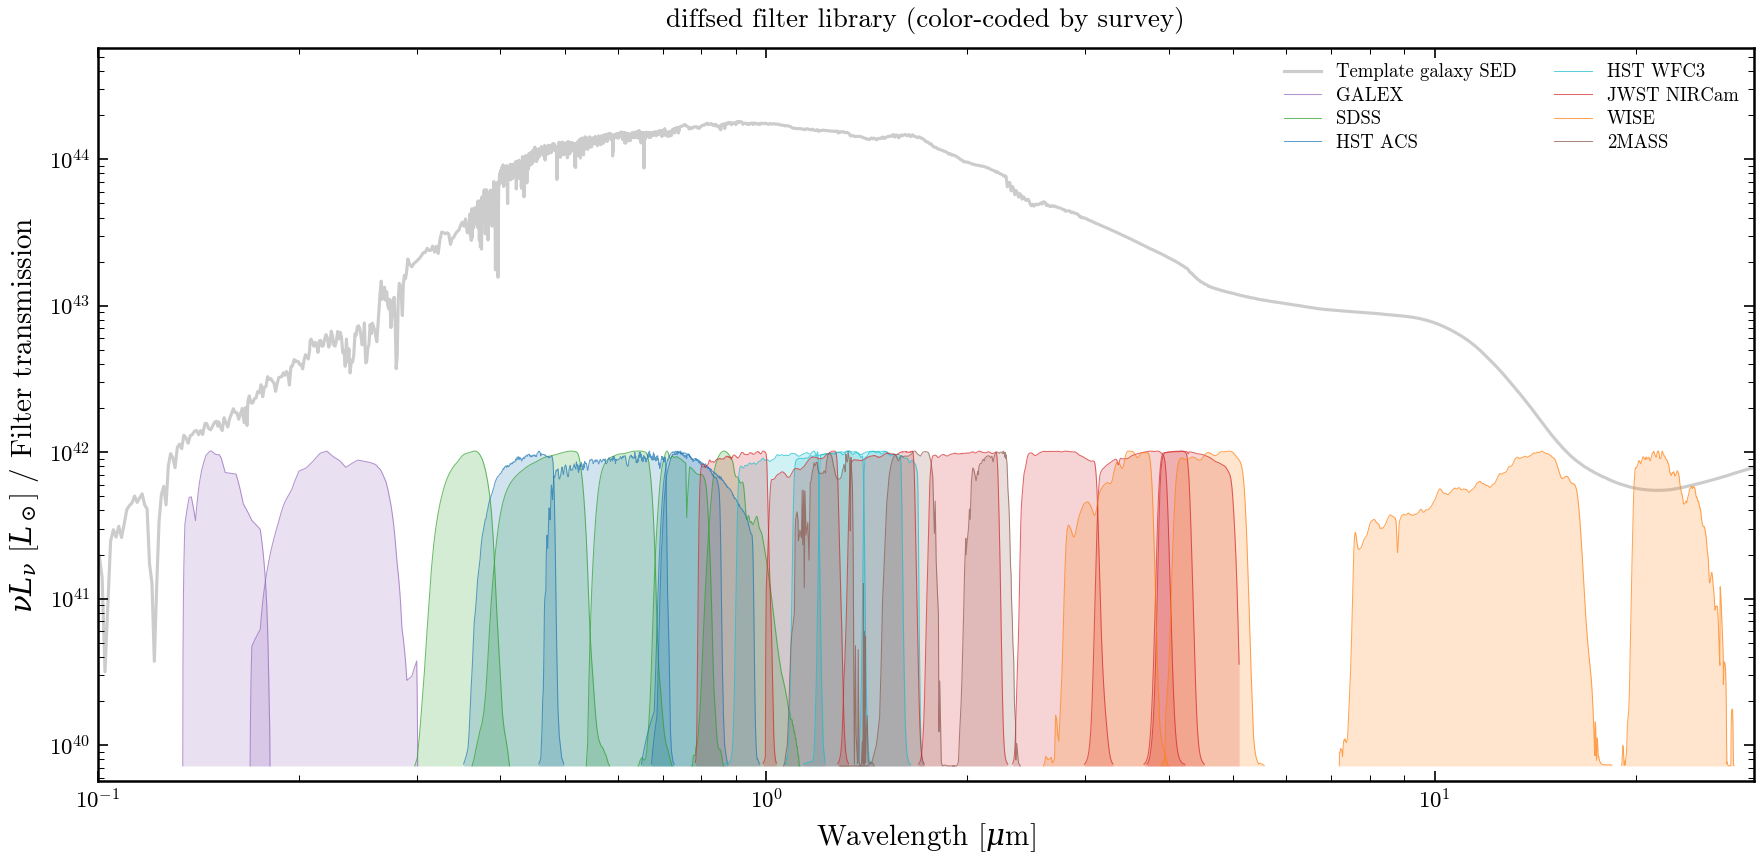

In [19]:
# Use a simple galaxy SED as background
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    spec_bg = ParamSpec(
        mean_sfh_type="dpl",
        sfh_dpl_alpha=Fixed(1.2), sfh_dpl_beta=Fixed(1.5),
        sfh_dpl_tau_gyr=Fixed(4.0), sfh_dpl_log_peak_sfr=Fixed(1.5),
        met_logzsol=Fixed(-0.3),
        dust_tau_bc=Fixed(0.4), dust_tau_diff=Fixed(0.2),
        dust_emission="draine_li2007",
        dust_umin=Fixed(2.0), dust_gamma_dl=Fixed(0.02), dust_qpah=Fixed(3.0),
        redshift=Fixed(0.0),
        apply_igm=False,
    )
    model_bg = Model(spec_bg, ssp, precompute=False, approx=False)

params_bg = spec_bg.sample(jax.random.PRNGKey(77))
sed_bg = np.array(model_bg.predict_sed(params_bg))

nuLnu_bg = sed_bg * nu_ssp
wave_aa_bg = np.array(ssp.ssp_wave)

fig, ax = plt.subplots(figsize=(12, 6))

# Background galaxy SED
mask_bg = nuLnu_bg > 0
ax.loglog(wave_aa_bg[mask_bg] / 1e4, nuLnu_bg[mask_bg],
          color="#cccccc", lw=1.5, zorder=1, label="Template galaxy SED")

# Determine y-range for filter scaling
log_y_max = np.log10(np.nanmax(nuLnu_bg[nuLnu_bg > 0])) + 0.5
log_y_min = log_y_max - 5.0  # 5 decades of dynamic range

# Plot each filter group
for group_name, (curves, color) in loaded_groups.items():
    for i, fc in enumerate(curves):
        fw = np.array(fc.wave)  # Angstrom
        ft = np.array(fc.trans)
        ft_norm = ft / ft.max()

        # Scale filter transmission to fill a band in the y-axis
        filt_base = 10**(log_y_min + 0.02 * (log_y_max - log_y_min))
        filt_top = 10**(log_y_min + 0.45 * (log_y_max - log_y_min))
        ft_scaled = filt_base + ft_norm * (filt_top - filt_base)

        label = group_name if i == 0 else None
        ax.fill_between(fw / 1e4, filt_base, ft_scaled,
                         alpha=0.20, color=color, lw=0, rasterized=True)
        ax.plot(fw / 1e4, ft_scaled, color=color, lw=0.5, alpha=0.7,
                label=label)

# Formatting
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [$L_\odot$] / Filter transmission")
ax.set_xlim(0.1, 30)
ax.set_ylim(10**(log_y_min), 10**(log_y_max))
ax.legend(loc="upper right", fontsize=9, ncol=2, handlelength=2.0)
ax.set_title("diffsed filter library (color-coded by survey)",
             fontsize=13, pad=10)

fig.tight_layout()
savefig(fig, "filter_library")
plt.show()

---
## Summary

Six publication-quality figures have been generated:

| Figure | File | Description |
|--------|------|-------------|
| 1 | `18_forward_model_pipeline` | Full physics pipeline buildup |
| 2 | `18_dust_attenuation_curves` | All 7 dust curves + UV bump inset |
| 3 | `18_agn_model_zoo` | All 6 AGN models at same $L_{\rm bol}$ |
| 4 | `18_parameter_degeneracies` | 2$\times$2 panel of classic degeneracies |
| 5 | `18_wavelength_coverage` | Panchromatic X-ray to radio coverage |
| 6 | `18_filter_library` | All filter sets on template galaxy SED |

All figures are saved in both PNG (300 DPI) and PDF formats in
`notebooks/figures/`.